In [1]:
# Install everything upfront — run this first, restart runtime after
!pip install gensim pyLDAvis wordcloud textblob nltk scikit-learn -q

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')

print("✓ All libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 34.9 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✓ All libraries installed


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Free up memory before loading
import gc
gc.collect()


# Adjust this path to wherever you put Reviews.csv in your Drive
FILE_PATH = '/content/drive/MyDrive/JTBD/Reviews.csv'

# Load — this is 568k rows so give it 30-60 seconds
print("Loading dataset...")
# df = pd.read_csv(FILE_PATH)

# Only load the columns you actually need
cols_needed = ['Id', 'ProductId', 'UserId', 'Score', 'Summary',
               'Text', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Time']

df = pd.read_csv(FILE_PATH, usecols=cols_needed)

print(f"✓ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumn names:", df.columns.tolist())
print("\nSample review:")
print(df['Text'].iloc[0][:300])

Mounted at /content/drive
Loading dataset...
✓ Loaded: 568,454 rows × 9 columns

Column names: ['Id', 'ProductId', 'UserId', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Sample review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


In [3]:
print(df.shape)
print(df.head(3))
print(df.dtypes)

(568454, 9)
   Id   ProductId          UserId  HelpfulnessNumerator  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                     1   
1   2  B00813GRG4  A1D87F6ZCVE5NK                     0   
2   3  B000LQOCH0   ABXLMWJIXXAIN                     1   

   HelpfulnessDenominator  Score        Time                Summary  \
0                       1      5  1303862400  Good Quality Dog Food   
1                       0      1  1346976000      Not as Advertised   
2                       1      4  1219017600  "Delight" says it all   

                                                Text  
0  I have bought several of the Vitality canned d...  
1  Product arrived labeled as Jumbo Salted Peanut...  
2  This is a confection that has been around a fe...  
Id                         int64
ProductId                 object
UserId                    object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary        

In [4]:
# Check nulls
print("=== NULL CHECK ===")
print(df.isnull().sum())

# Drop rows with no review text
df = df.dropna(subset=['Text', 'Score'])
df = df.reset_index(drop=True)

# Remove duplicates (same user reviewing same product multiple times)
df = df.drop_duplicates(subset=['UserId', 'ProductId'])
df = df.reset_index(drop=True)

# Parse timestamp
df['review_date'] = pd.to_datetime(df['Time'], unit='s')
df['review_year'] = df['review_date'].dt.year
df['review_month'] = df['review_date'].dt.month

# Calculate helpfulness ratio (avoid divide by zero)
df['helpfulness_ratio'] = np.where(
    df['HelpfulnessDenominator'] > 0,
    df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'],
    np.nan
)

# Create sentiment buckets from star rating
def rating_to_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['star_sentiment'] = df['Score'].apply(rating_to_sentiment)

# Flag highly helpful reviews (the ones with wisdom)
df['is_helpful'] = (
    (df['HelpfulnessDenominator'] >= 5) &
    (df['helpfulness_ratio'] >= 0.75)
).astype(int)

print(f"\n✓ Clean dataset: {len(df):,} rows")
print(f"\nSentiment split:")
print(df['star_sentiment'].value_counts())
print(f"\nHighly helpful reviews: {df['is_helpful'].sum():,}")

=== NULL CHECK ===
Id                         0
ProductId                  0
UserId                     0
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

✓ Clean dataset: 560,804 rows

Sentiment split:
star_sentiment
Positive    437760
Negative     81005
Neutral      42039
Name: count, dtype: int64

Highly helpful reviews: 44,339


In [5]:
# Save checkpoint after each major cell
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_PATH = '/content/drive/MyDrive/JTBD/checkpoints/'
import os
os.makedirs(CHECKPOINT_PATH, exist_ok=True)
print("✓ Checkpoint folder ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Checkpoint folder ready


In [6]:
# Save cleaned dataframe — so if runtime dies you don't re-clean
df.to_pickle(CHECKPOINT_PATH + 'df_clean.pkl')
print("✓ Checkpoint saved")

✓ Checkpoint saved


In [7]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add domain-specific stops — words that appear everywhere but mean nothing
custom_stops = {
    'product', 'amazon', 'buy', 'bought', 'purchase', 'ordered', 'order',
    'one', 'get', 'got', 'also', 'really', 'just', 'like', 'would',
    'much', 'very', 'great', 'good', 'love', 'use', 'used', 'using'
}
stop_words.update(custom_stops)

def clean_text(text):
    """Full preprocessing: lowercase → remove punct → tokenize → remove stops → lemmatize"""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)           # remove HTML tags
    text = re.sub(r'http\S+', '', text)            # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)         # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()       # normalize whitespace

    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens   # returns list of tokens (needed for LDA)

def clean_text_string(text):
    """Same but returns a string (needed for VADER and TF-IDF)"""
    return ' '.join(clean_text(text))

# Apply to a working sample first (LDA on 393k reviews is slow)
# For capstone, use 80k — statistically solid and fast
print("Sampling 100,000 reviews for modeling...")
# df_sample = df.sample(n=80000, random_state=42).reset_index(drop=True)

# Stratified sample — keep ALL highly helpful + 56k random rest
helpful = df[df['is_helpful'] == 1]
not_helpful = df[df['is_helpful'] == 0].sample(n=55662, random_state=42)

df_sample = pd.concat([helpful, not_helpful]).reset_index(drop=True)

print(f"Total working sample: {len(df_sample):,}")
print(f"Helpful reviews: {len(helpful):,}")
print(f"Non-helpful reviews: {len(not_helpful):,}")


print("Cleaning text... (this takes 3-5 minutes)")
df_sample['tokens'] = df_sample['Text'].apply(clean_text)
df_sample['clean_text'] = df_sample['tokens'].apply(lambda t: ' '.join(t))

print(f"✓ Text cleaning complete")
print(f"\nExample original: {df_sample['Text'].iloc[0][:100]}")
print(f"Example cleaned:  {df_sample['clean_text'].iloc[0][:100]}")

Sampling 100,000 reviews for modeling...
Total working sample: 100,001
Helpful reviews: 44,339
Non-helpful reviews: 55,662
Cleaning text... (this takes 3-5 minutes)
✓ Text cleaning complete

Example original: The Strawberry Twizzlers are my guilty pleasure - yummy. Six pounds will be around for a while with 
Example cleaned:  strawberry twizzlers guilty pleasure yummy six pound around son


In [8]:
df_sample.to_pickle(CHECKPOINT_PATH + 'df_sample.pkl')
print("✓ Sample checkpoint saved")

✓ Sample checkpoint saved


In [9]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

print("Running VADER sentiment analysis...")
df_sample['vader_compound'] = df_sample['Text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)
df_sample['vader_pos'] = df_sample['Text'].apply(
    lambda x: sia.polarity_scores(str(x))['pos']
)
df_sample['vader_neg'] = df_sample['Text'].apply(
    lambda x: sia.polarity_scores(str(x))['neg']
)

# Map compound score to label
def vader_label(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

df_sample['vader_sentiment'] = df_sample['vader_compound'].apply(vader_label)

# Agreement between stars and VADER
df_sample['sentiment_agreement'] = (
    df_sample['star_sentiment'] == df_sample['vader_sentiment']
).astype(int)

print(f"✓ VADER complete")
print(f"\nVADER sentiment distribution:")
print(df_sample['vader_sentiment'].value_counts())
print(f"\nStar ↔ VADER agreement rate: {df_sample['sentiment_agreement'].mean():.1%}")

Running VADER sentiment analysis...
✓ VADER complete

VADER sentiment distribution:
vader_sentiment
Positive    87273
Negative    10803
Neutral      1925
Name: count, dtype: int64

Star ↔ VADER agreement rate: 79.5%


In [10]:
# Save current df_sample as CSV checkpoint
df_sample.to_csv(CHECKPOINT_PATH + 'df_sample_checkpoint.csv', index=False)

# Also save as pkl (faster to reload)
df_sample.to_pickle(CHECKPOINT_PATH + 'df_sample.pkl')

print(f"✓ CSV saved: {CHECKPOINT_PATH}df_sample_checkpoint.csv")
print(f"✓ PKL saved: {CHECKPOINT_PATH}df_sample.pkl")
print(f"Rows saved: {len(df_sample):,}")
print(f"Columns saved: {df_sample.columns.tolist()}")


✓ CSV saved: /content/drive/MyDrive/JTBD/checkpoints/df_sample_checkpoint.csv
✓ PKL saved: /content/drive/MyDrive/JTBD/checkpoints/df_sample.pkl
Rows saved: 100,001
Columns saved: ['Id', 'ProductId', 'UserId', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_date', 'review_year', 'review_month', 'helpfulness_ratio', 'star_sentiment', 'is_helpful', 'tokens', 'clean_text', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_sentiment', 'sentiment_agreement']


In [11]:
# import pandas as pd
# from google.colab import drive
# drive.mount('/content/drive')

# CHECKPOINT_PATH = '/content/drive/MyDrive/JTBD/checkpoints/'
# df_sample = pd.read_pickle(CHECKPOINT_PATH + 'df_sample.pkl')
# print(f"✓ Resumed: {df_sample.shape[0]:,} rows, {df_sample.shape[1]} columns")

In [12]:
# Define JTBD "jobs" for food/grocery products
# These are the functional reasons people buy food products on Amazon
jtbd_jobs = {
    'Health & Nutrition':     ['organic', 'protein', 'calorie', 'vitamin', 'healthy',
                                'nutrition', 'diet', 'gluten', 'sugar', 'sodium', 'fat',
                                'fiber', 'antioxidant', 'natural', 'supplement', 'low sugar', 'high protein', 'no preservatives',
                           'all natural', 'non gmo', 'low sodium', 'memory', 'digestive', 'digestion',
                                    'immune', 'energy', 'wellness'],

    'Taste & Enjoyment':      ['taste', 'flavor', 'delicious', 'yummy', 'bland', 'sweet',
                                'salty', 'bitter', 'fresh', 'stale', 'aroma', 'texture',
                                'crunchy', 'soft', 'rich', 'chocolate', 'candy', 'coffee', 'blend',
                                    'smooth', 'cook', 'cooking', 'salt', 'sauce',
                                    'addictive', 'oversalted', 'tea'],

    'Convenience & Speed':    ['quick', 'easy', 'convenient', 'instant', 'fast', 'ready',
                                'microwave', 'simple', 'prep', 'minutes', 'busy', 'meal prep', 'easy to make', 'no prep', 'grab and go',
                              'single serve', 'on the go'],

    'Family & Kids':          ['kid', 'child', 'children', 'family', 'son', 'daughter',
                                'baby', 'toddler', 'school', 'lunch', 'snack', 'picky'],

    'Pet Care':               ['dog', 'cat', 'pet', 'puppy', 'kitten', 'fur', 'paw',
                                'breed', 'vet', 'treat', 'kibble', 'senior dog', 'chewer', 'chew', 'toy', 'pup', 'puppy',
                                    'destroy', 'aggressive chewer'],

    'Special Diet':           ['keto', 'vegan', 'vegetarian', 'paleo', 'diabetic',
                                'lactose', 'allergy', 'intolerance', 'celiac', 'low carb',
                                'dairy free', 'nut free', 'dairy free', 'gluten free', 'nut free',
                              'low carb', 'sugar free', 'grain free', 'free of', 'light food', 'low calorie',
                                    'fat free', 'sugar free'],

    'Value & Bulk Buying':    ['price', 'value', 'cheap', 'expensive', 'afford', 'bulk',
                                'subscribe', 'save', 'deal', 'worth', 'cost', 'compared', 'buy a case', 'team up', 'website price',
                                    'cheaper elsewhere', 'best price'],

    'Gifting & Occasion':     ['gift', 'present', 'birthday', 'holiday', 'christmas',
                                'party', 'wedding', 'host', 'guest', 'basket', 'occasion'],

    'Quality & Freshness':    ['fresh', 'expired', 'stale', 'quality', 'packaging',
                                'seal', 'leak', 'damage', 'broken', 'melted', 'arrived',
                                'shipping', 'box', 'fell apart', 'went bad', 'not fresh',
                             'poorly packaged', 'broken seal', 'crushed box', 'discolored', 'mold', 'moldy', 'dust',
                                    'dark', 'dry', 'bad batch'],

    'Repeat Purchase':        ['reorder', 'repurchase', 'again', 'always buy', 'staple',
                                'stock', 'regular', 'subscribe', 'monthly', 'running out', 'will order again', 'come back', 'keep buying',
                              'never run out', 'always have']
}

def tag_jtbd(text):
    text_lower = str(text).lower()
    tags = []
    for job, keywords in jtbd_jobs.items():
        if any(kw in text_lower for kw in keywords):
            tags.append(job)
    return tags if tags else ['Unclassified']

print("Tagging JTBD jobs...")
df_sample['jtbd_tags'] = df_sample['Text'].apply(tag_jtbd)
df_sample['jtbd_count'] = df_sample['jtbd_tags'].apply(len)

# Explode for analysis
df_tags = df_sample.explode('jtbd_tags').reset_index(drop=True)

print(f"✓ Tagging complete")
print(f"\nJTBD Job Frequency:")
print(df_tags['jtbd_tags'].value_counts())
print(f"\nAvg jobs per review: {df_sample['jtbd_count'].mean():.2f}")
print(f"Reviews with multiple jobs: {(df_sample['jtbd_count'] > 1).mean():.1%}")

Tagging JTBD jobs...
✓ Tagging complete

JTBD Job Frequency:
jtbd_tags
Taste & Enjoyment      72434
Quality & Freshness    34105
Health & Nutrition     33092
Value & Bulk Buying    31969
Family & Kids          26022
Pet Care               23158
Convenience & Speed    22827
Repeat Purchase        19039
Gifting & Occasion      6946
Special Diet            6250
Unclassified            3894
Name: count, dtype: int64

Avg jobs per review: 2.80
Reviews with multiple jobs: 77.2%


In [13]:
unclassified_reviews = df_sample[
    df_sample['jtbd_tags'].apply(lambda x: x == ['Unclassified'])
]['Text'].sample(20, random_state=42).tolist()

for i, review in enumerate(unclassified_reviews[:10]):
    print(f"\n--- Review {i+1} ---")
    print(review[:200])


--- Review 1 ---
Been using for years and still alive.<br />Been using for years and still alive.<br />Been using for years and still alive.<br />Been using for years and still alive.

--- Review 2 ---
The jerky I got from Amazon is tough and unedible. I usually buy this item from GNC and never had a issue with them.

--- Review 3 ---
Would have been great for baking or making ice cream, as most of the mints were smashed beyond all recognition.

--- Review 4 ---
What is there to say it is pudding!!! It is great I like it, that is why I bought it.

--- Review 5 ---
I love it...but you can find it at sams club for $6 versus the $14 here on amazon.

--- Review 6 ---
$9 for a 1 lb of pasta????? What is this?? I don't want even to try it. I am pretty sure this is a good product and De Cecco is very well known name, however......

--- Review 7 ---
Good stuff -- but make sure you have a bottle to decant into. You will just make a mess if you try to pour from this container.

--- Review 8 ---

In [14]:
# Save after JTBD tagging — Cell 7 (LDA) is the longest cell
df_sample.to_pickle(CHECKPOINT_PATH + 'df_sample_jtbd_tagged.pkl')
df_tags.to_pickle(CHECKPOINT_PATH + 'df_tags.pkl')

print(f"✓ df_sample saved: {len(df_sample):,} rows")
print(f"✓ df_tags saved: {len(df_tags):,} rows")

✓ df_sample saved: 100,001 rows
✓ df_tags saved: 279,736 rows


In [15]:
df_sample.to_pickle(CHECKPOINT_PATH + 'df_sample_jtbd_tagged.pkl')
df_tags.to_pickle(CHECKPOINT_PATH + 'df_tags.pkl')
print(f"✓ Saved — df_sample: {len(df_sample):,} | df_tags: {len(df_tags):,}")

✓ Saved — df_sample: 100,001 | df_tags: 279,736


In [16]:
from gensim import corpora, models
from gensim.models import CoherenceModel

# Build dictionary and corpus for LDA
print("Building LDA corpus...")
texts = df_sample['tokens'].tolist()

# Filter extremes — ignore words appearing in <5 or >50% of docs
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in texts]
print(f"✓ Dictionary size: {len(dictionary):,} unique terms")
print(f"✓ Corpus: {len(corpus):,} documents")

# Train LDA — 10 topics is the sweet spot for this dataset
print("\nTraining LDA model (5-10 minutes)...")
lda_model = models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    chunksize=2000,
    passes=10,
    alpha='asymmetric',   # asymmetric prior works better for reviews
    eta='auto',
    workers=2
)

print("✓ LDA training complete!")
print("\nTop words per topic:")
for idx, topic in lda_model.print_topics(-1, num_words=8):
    words = [w.split('"')[1] for w in topic.split('+')]
    print(f"  Topic {idx:2d}: {' | '.join(words)}")

Building LDA corpus...
✓ Dictionary size: 18,271 unique terms
✓ Corpus: 100,001 documents

Training LDA model (5-10 minutes)...
✓ LDA training complete!

Top words per topic:
  Topic  0: price | store | box | bag | time | find | shipping | local
  Topic  1: tea | flavor | taste | drink | water | green | make | sweet
  Topic  2: food | dog | cat | treat | love | eat | old | year
  Topic  3: day | work | time | popcorn | take | help | stuff | taste
  Topic  4: coffee | complexity | cup | flavor | medium | taste | still | little
  Topic  5: little | flavor | spicy | heat | stuff | food | curry | hotter
  Topic  6: reverse | ingredient | organic | protein | fat | food | sugar | calorie
  Topic  7: sugar | mix | milk | taste | make | free | gluten | add
  Topic  8: make | soup | rice | chicken | add | pasta | flavor | easy
  Topic  9: taste | chocolate | flavor | snack | chip | bar | sweet | eat


In [17]:
# Human-readable topic names (update these based on YOUR actual output)
topic_names = {
    0: 'General Product Experience',
    1: 'Tea & Beverages',
    2: 'Pet Food & Treats',
    3: 'Daily Use & Supplements',
    4: 'Coffee & Roasts',
    5: 'Cooking Ingredients & Sauces',
    6: 'Organic & Nutrition Labels',
    7: 'Baking & Dietary Needs',
    8: 'Meal Prep & Easy Cooking',
    9: 'Snacks & Chocolate'
}

# Assign dominant topic to each review
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1, 0.0
    dominant = max(topics, key=lambda x: x[1])
    return dominant[0], round(dominant[1], 3)

print("Assigning dominant topics to reviews...")
topic_assignments = [get_dominant_topic(bow) for bow in corpus]
df_sample['lda_topic_id'] = [t[0] for t in topic_assignments]
df_sample['lda_topic_confidence'] = [t[1] for t in topic_assignments]
df_sample['lda_topic_name'] = df_sample['lda_topic_id'].map(topic_names)

print(f"✓ Topic assignment complete")
print(f"\nTopic distribution:")
print(df_sample['lda_topic_name'].value_counts())
print(f"\nAverage topic confidence: {df_sample['lda_topic_confidence'].mean():.3f}")

Assigning dominant topics to reviews...
✓ Topic assignment complete

Topic distribution:
lda_topic_name
General Product Experience      25416
Snacks & Chocolate              14458
Pet Food & Treats               11379
Tea & Beverages                 10526
Coffee & Roasts                  9446
Meal Prep & Easy Cooking         8201
Baking & Dietary Needs           7777
Daily Use & Supplements          7336
Organic & Nutrition Labels       3233
Cooking Ingredients & Sauces     2229
Name: count, dtype: int64

Average topic confidence: 0.616


In [18]:
# Save LDA model and topic assignments
df_sample.to_pickle(CHECKPOINT_PATH + 'df_sample_lda.pkl')
lda_model.save(CHECKPOINT_PATH + 'lda_model')
print("✓ LDA model and assignments saved")

✓ LDA model and assignments saved


Building TF-IDF matrix...
✓ TF-IDF matrix: (100001, 3000)

Finding optimal number of clusters...
  K=3: inertia=96337
  K=4: inertia=95514
  K=5: inertia=95090
  K=6: inertia=94764
  K=7: inertia=94497
  K=8: inertia=94236
  K=9: inertia=94028
  K=10: inertia=93795
  K=11: inertia=93605


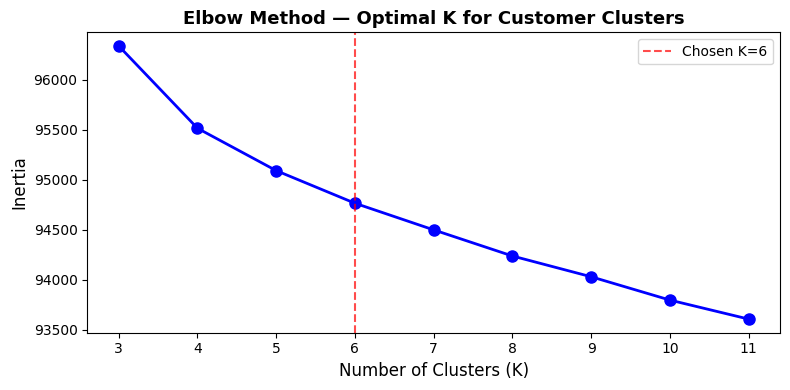

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Build TF-IDF matrix
print("Building TF-IDF matrix...")
tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2)    # unigrams + bigrams — captures "not good", "very fresh" etc.
)
tfidf_matrix = tfidf.fit_transform(df_sample['clean_text'])
print(f"✓ TF-IDF matrix: {tfidf_matrix.shape}")

# Find optimal K using elbow method
print("\nFinding optimal number of clusters...")
inertias = []
K_range = range(3, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)
    print(f"  K={k}: inertia={km.inertia_:.0f}")

# Plot elbow
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method — Optimal K for Customer Clusters', fontsize=13, fontweight='bold')
plt.axvline(x=6, color='red', linestyle='--', alpha=0.7, label='Chosen K=6')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Train with K=6 (adjust based on your elbow plot)
OPTIMAL_K = 7

print(f"Training K-Means with K={OPTIMAL_K}...")
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_sample['cluster'] = km_final.fit_predict(tfidf_matrix)

# Find top terms per cluster (what defines each group?)
feature_names = tfidf.get_feature_names_out()
cluster_centers = km_final.cluster_centers_

print("\nTop terms per cluster:")
for i in range(OPTIMAL_K):
    top_indices = cluster_centers[i].argsort()[-10:][::-1]
    top_terms = [feature_names[idx] for idx in top_indices]
    print(f"\n  Cluster {i}: {' | '.join(top_terms)}")

# Name your clusters based on the terms (update after seeing output)
cluster_names = {
    0: 'Mainstream Food Buyers',
    1: 'Dedicated Dog Owners',
    2: 'Snack & Cooking Enthusiasts',
    3: 'Tea Drinkers',
    4: 'Dedicated Cat Owners',
    5: 'Indulgent Snack Seekers',
    6: 'Coffee Aficionados'
}
df_sample['cluster_name'] = df_sample['cluster'].map(cluster_names)

print(f"\n✓ Cluster distribution:")
print(df_sample['cluster_name'].value_counts())

Training K-Means with K=7...

Top terms per cluster:

  Cluster 0: taste | flavor | make | price | time | store | little | best | find | food

  Cluster 1: dog | treat | food | dog food | love | chew | dog love | pet | bag | bone

  Cluster 2: chip | salt | oil | popcorn | taste | bag | coconut | flavor | olive | coconut oil

  Cluster 3: tea | green tea | green | flavor | taste | bag | drink | cup | tea bag | leaf

  Cluster 4: cat | food | cat food | eat | dry | chicken | treat | vet | diet | canned

  Cluster 5: chocolate | bar | peanut | taste | butter | peanut butter | flavor | dark chocolate | dark | snack

  Cluster 6: coffee | cup | flavor | roast | taste | cup coffee | strong | bold | blend | keurig

✓ Cluster distribution:
cluster_name
Mainstream Food Buyers         61706
Coffee Aficionados              9057
Tea Drinkers                    6831
Dedicated Dog Owners            6802
Indulgent Snack Seekers         6335
Snack & Cooking Enthusiasts     6013
Dedicated Cat Owners  

Running PCA for cluster visualization...


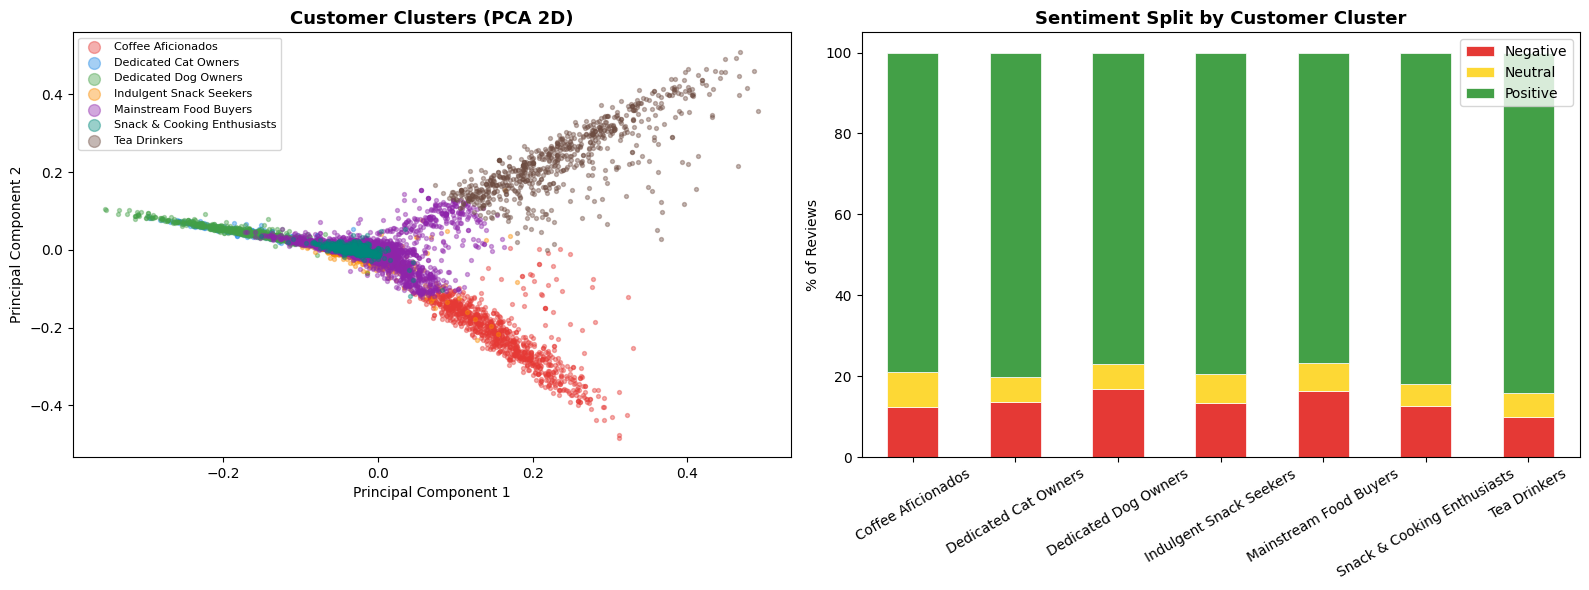

✓ Saved: cluster_analysis.png


In [21]:
# Reduce to 2D for visualization
print("Running PCA for cluster visualization...")
pca = PCA(n_components=2, random_state=42)

# PCA on a 10k sample (80k would be too slow to plot)
sample_idx = np.random.choice(len(df_sample), size=10000, replace=False)
tfidf_sample = tfidf_matrix[sample_idx]
pca_coords = pca.fit_transform(tfidf_sample.toarray())

plot_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'Cluster': df_sample['cluster_name'].iloc[sample_idx].values,
    'Sentiment': df_sample['star_sentiment'].iloc[sample_idx].values
})

# Cluster scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#e53935', '#1e88e5', '#43a047', '#fb8c00', '#8e24aa', '#00897b', '#6d4c41']
for i, (name, group) in enumerate(plot_df.groupby('Cluster')):
    axes[0].scatter(group['PC1'], group['PC2'],
                    label=name, alpha=0.4, s=8, color=colors[i])

axes[0].set_title('Customer Clusters (PCA 2D)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8, markerscale=3)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Sentiment distribution per cluster
cluster_sentiment = df_sample.groupby(['cluster_name', 'star_sentiment']).size().unstack(fill_value=0)
cluster_sentiment_pct = cluster_sentiment.div(cluster_sentiment.sum(axis=1), axis=0) * 100

cluster_sentiment_pct[['Negative', 'Neutral', 'Positive']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#e53935', '#fdd835', '#43a047'],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('Sentiment Split by Customer Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='upper right')
axes[1].set_ylabel('% of Reviews')

plt.tight_layout()
plt.savefig('cluster_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cluster_analysis.png")

In [22]:
print(df_tags.columns.tolist())

['Id', 'ProductId', 'UserId', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_date', 'review_year', 'review_month', 'helpfulness_ratio', 'star_sentiment', 'is_helpful', 'tokens', 'clean_text', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_sentiment', 'sentiment_agreement', 'jtbd_tags', 'jtbd_count']


In [23]:
print(df_sample.columns.tolist())

['Id', 'ProductId', 'UserId', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_date', 'review_year', 'review_month', 'helpfulness_ratio', 'star_sentiment', 'is_helpful', 'tokens', 'clean_text', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_sentiment', 'sentiment_agreement', 'jtbd_tags', 'jtbd_count', 'lda_topic_id', 'lda_topic_confidence', 'lda_topic_name', 'cluster', 'cluster_name']


In [24]:
# Save LDA model and topic assignments
df_sample.to_pickle(CHECKPOINT_PATH + 'df_sample_Pca_Viz.pkl')
lda_model.save(CHECKPOINT_PATH + 'lda_model')
print("✓ LDA model and assignments saved")

✓ LDA model and assignments saved


In [27]:
# Create unmet_need column first
df_sample['unmet_need'] = (
    (df_sample['vader_sentiment'] == 'Negative') &
    (df_sample['Score'] <= 2) &
    (df_sample['jtbd_count'] >= 1) &
    (df_sample['helpfulness_ratio'] >= 0.6)
).astype(int)

print(f"✓ Unmet need column created")
print(f"Total unmet need signals: {df_sample['unmet_need'].sum():,}")
print(f"That's {df_sample['unmet_need'].mean():.1%} of all reviews")

✓ Unmet need column created
Total unmet need signals: 3,582
That's 3.6% of all reviews


In [28]:
# Sync unmet_need to df_tags
df_tags = df_sample.explode('jtbd_tags').reset_index(drop=True)
print(f"✓ df_tags refreshed: {len(df_tags):,} rows")

✓ df_tags refreshed: 279,736 rows


In [29]:
# UNMET NEEDS = reviews where:
# - Customer had a clear functional job (JTBD tagged)
# - But the product failed (negative sentiment, low rating)
# - AND the review was helpful (others agreed this was a real problem)

# This is the most valuable output for a product team

df_sample['unmet_need'] = (
    (df_sample['vader_sentiment'] == 'Negative') &
    (df_sample['Score'] <= 2) &
    (df_sample['jtbd_count'] >= 1) &
    (df_sample['helpfulness_ratio'] >= 0.6)
).astype(int)

unmet_by_job = (
    df_tags[df_tags['unmet_need'] == 1]
    .groupby('jtbd_tags')
    .agg(
        unmet_reviews=('Id', 'count'),
        avg_rating=('Score', 'mean'),
        avg_helpfulness=('helpfulness_ratio', 'mean')
    )
    .round(2)
    .sort_values('unmet_reviews', ascending=False)
)

print("=== UNMET NEEDS BY CUSTOMER JOB ===")
print(unmet_by_job)
print(f"\nTotal unmet need signals: {df_sample['unmet_need'].sum():,}")
print(f"That's {df_sample['unmet_need'].mean():.1%} of all reviews")

=== UNMET NEEDS BY CUSTOMER JOB ===
                     unmet_reviews  avg_rating  avg_helpfulness
jtbd_tags                                                      
Taste & Enjoyment             2087        1.27             0.89
Quality & Freshness           1490        1.23             0.89
Value & Bulk Buying            964        1.23             0.90
Pet Care                       923        1.18             0.88
Repeat Purchase                793        1.24             0.90
Health & Nutrition             787        1.23             0.88
Family & Kids                  697        1.21             0.88
Convenience & Speed            438        1.23             0.90
Gifting & Occasion             238        1.16             0.90
Unclassified                   206        1.17             0.90
Special Diet                   107        1.17             0.86

Total unmet need signals: 3,582
That's 3.6% of all reviews


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Goal: predict whether a review will be found "helpful" by others
# This answers: "What makes a review trustworthy and useful?"

# Features for the model
model_df = df_sample[df_sample['HelpfulnessDenominator'] >= 5].copy()
model_df = model_df.dropna(subset=['helpfulness_ratio', 'vader_compound'])

# Feature engineering
model_df['review_length'] = model_df['Text'].str.len()
model_df['word_count'] = model_df['clean_text'].str.split().str.len()
model_df['has_multiple_jobs'] = (model_df['jtbd_count'] > 1).astype(int)
model_df['sentiment_mismatch'] = (model_df['sentiment_agreement'] == 0).astype(int)
model_df['topic_confidence'] = model_df['lda_topic_confidence']

# Build feature matrix
feature_cols = [
    'Score', 'vader_compound', 'vader_neg', 'vader_pos',
    'review_length', 'word_count', 'jtbd_count',
    'has_multiple_jobs', 'sentiment_mismatch', 'topic_confidence'
]

X = model_df[feature_cols].fillna(0)
y = model_df['is_helpful']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression (interpretable — great for DA roles)
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== HELPFULNESS PREDICTION MODEL ===")
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("\nTop predictors of helpfulness:")
print(coef_df)

=== HELPFULNESS PREDICTION MODEL ===

ROC-AUC Score: 0.827

Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.79      0.27       478
           1       0.99      0.78      0.87      8869

    accuracy                           0.78      9347
   macro avg       0.57      0.78      0.57      9347
weighted avg       0.94      0.78      0.84      9347


Top predictors of helpfulness:
              feature  coefficient
2           vader_neg     1.631694
0               Score     0.575530
1      vader_compound     0.500232
9    topic_confidence     0.364039
7   has_multiple_jobs     0.217847
6          jtbd_count     0.115117
4       review_length     0.000648
5          word_count    -0.006977
8  sentiment_mismatch    -0.556500
3           vader_pos    -1.112337


In [31]:
# Save all current state
df_sample.to_pickle(CHECKPOINT_PATH + 'df_sample_model.pkl')
df_tags.to_pickle(CHECKPOINT_PATH + 'df_tags_model.pkl')

# Save model results as CSV
coef_df.to_csv(CHECKPOINT_PATH + 'helpfulness_model_coefficients.csv', index=False)

print("✓ All saved")
print(f"df_sample: {len(df_sample):,} rows")
print(f"df_tags: {len(df_tags):,} rows")

✓ All saved
df_sample: 100,001 rows
df_tags: 279,736 rows


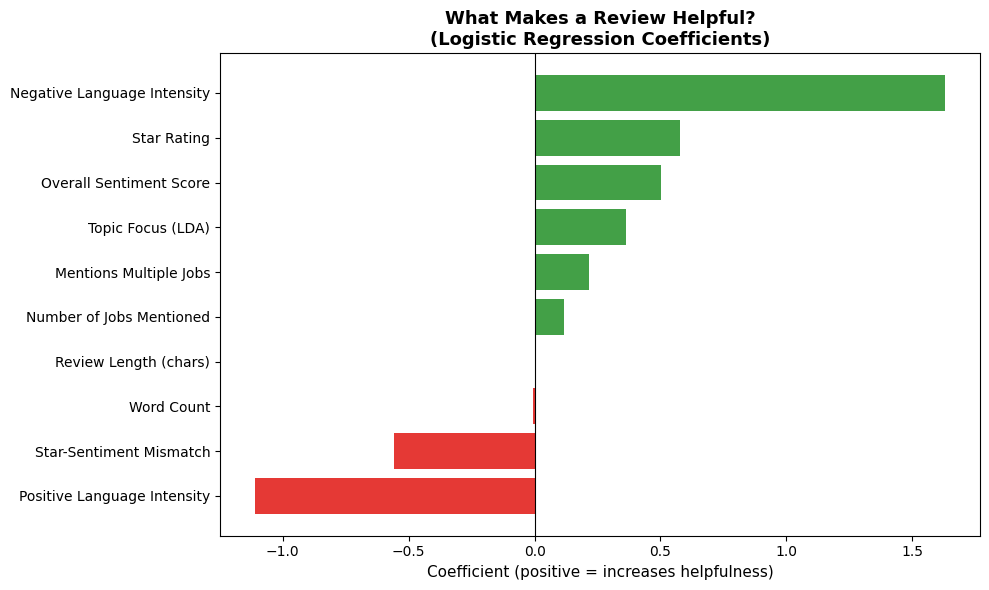

✓ Saved: helpfulness_model.png


In [35]:
import matplotlib.pyplot as plt

# Human readable labels
label_map = {
    'vader_neg':          'Negative Language Intensity',
    'Score':              'Star Rating',
    'vader_compound':     'Overall Sentiment Score',
    'topic_confidence':   'Topic Focus (LDA)',
    'has_multiple_jobs':  'Mentions Multiple Jobs',
    'jtbd_count':         'Number of Jobs Mentioned',
    'review_length':      'Review Length (chars)',
    'word_count':         'Word Count',
    'sentiment_mismatch': 'Star-Sentiment Mismatch',
    'vader_pos':          'Positive Language Intensity'
}

coef_plot = coef_df.copy()
coef_plot['feature'] = coef_plot['feature'].map(label_map)
coef_plot = coef_plot.sort_values('coefficient', ascending=True)

colors = ['#e53935' if c < 0 else '#43a047' for c in coef_plot['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef_plot['feature'], coef_plot['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('What Makes a Review Helpful?\n(Logistic Regression Coefficients)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient (positive = increases helpfulness)', fontsize=11)
plt.tight_layout()
plt.savefig('helpfulness_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: helpfulness_model.png")

In [36]:
# Save the figure permanently to Drive
import shutil
shutil.copy('helpfulness_model.png', CHECKPOINT_PATH + 'helpfulness_model.png')
print("✓ Saved to Drive")

✓ Saved to Drive


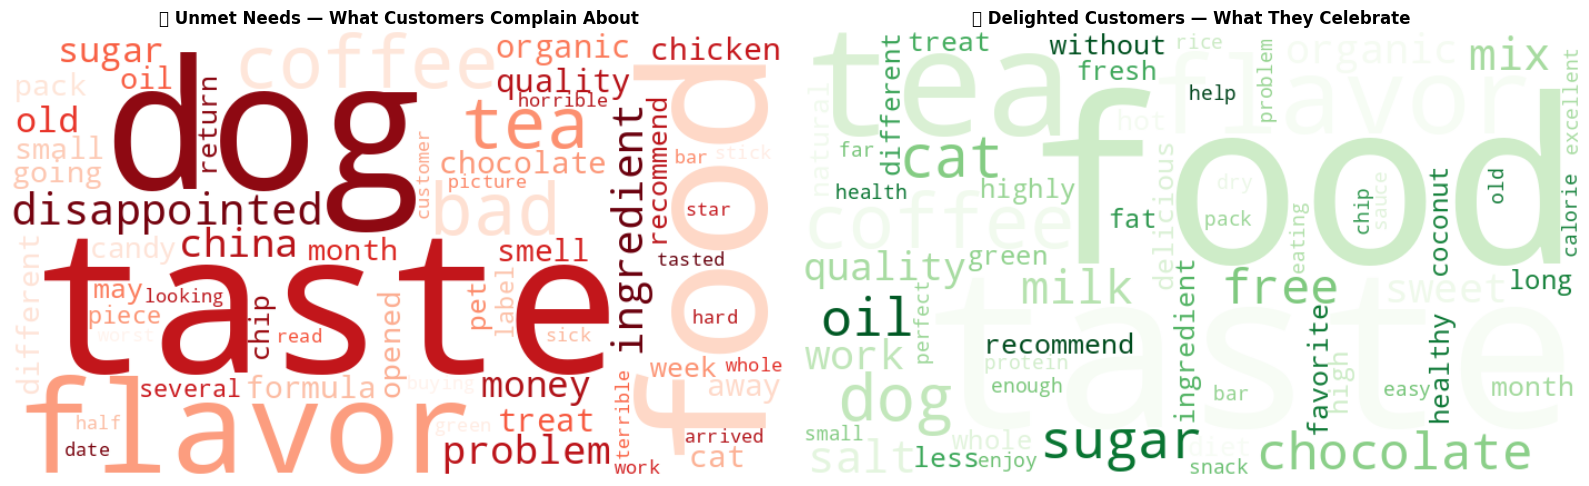

✓ Saved: wordclouds.png


In [39]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

# Build stop words once — hardcoded so it never gets overwritten
all_stops = set(stopwords.words('english')).union({
    # Generic verbs
    'make', 'made', 'find', 'found', 'know', 'think', 'say', 'said',
    'put', 'got', 'get', 'come', 'came', 'went', 'go', 'try', 'tried',
    'eat', 'ate', 'drink', 'bought', 'buy', 'purchasing', 'purchased',
    'use', 'used', 'using', 'get', 'give', 'given', 'keep', 'kept',
    # Filler words
    'even', 'still', 'well', 'way', 'thing', 'things', 'stuff', 'little',
    'much', 'many', 'since', 'though', 'however', 'never', 'ever', 'back',
    'need', 'want', 'time', 'first', 'last', 'new', 'add', 'two', 'lot',
    'almost', 'another', 'something', 'anything', 'everything', 'nothing',
    'sure', 'thought', 'better', 'best', 'great', 'good', 'nice', 'love',
    'would', 'could', 'also', 'one', 'see', 'look', 'right', 'left',
    'always', 'alway', 'never', 'every', 'bit', 'take', 'took', 'come',
    # Generic nouns
    'item', 'product', 'review', 'company', 'brand', 'people', 'day',
    'year', 'case', 'box', 'bag', 'bottle', 'cup', 'price', 'water',
    'place', 'store', 'amazon', 'order', 'ordered', 'ordering', 'receive',
    'received', 'package', 'packaging', 'shipping', 'ship'
})

# Build text corpora
unmet_text = ' '.join(
    df_sample[df_sample['unmet_need'] == 1]['clean_text'].tolist()
)

delight_text = ' '.join(
    df_sample[
        (df_sample['Score'] == 5) &
        (df_sample['is_helpful'] == 1)
    ]['clean_text'].tolist()
)

# Generate word clouds
wc_unmet = WordCloud(
    width=700, height=400,
    background_color='white',
    colormap='Reds',
    max_words=60,
    stopwords=all_stops,
    collocations=False
).generate(unmet_text)

wc_delight = WordCloud(
    width=700, height=400,
    background_color='white',
    colormap='Greens',
    max_words=60,
    stopwords=all_stops,
    collocations=False
).generate(delight_text)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_unmet, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🔴 Unmet Needs — What Customers Complain About',
                   fontsize=12, fontweight='bold')

axes[1].imshow(wc_delight, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🟢 Delighted Customers — What They Celebrate',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: wordclouds.png")

In [40]:
import shutil
shutil.copy('wordclouds.png', CHECKPOINT_PATH + 'wordclouds.png')
print("✓ Wordclouds saved to Drive")

✓ Wordclouds saved to Drive


✓ df_tags refreshed: 279,736 rows
Columns: ['Id', 'ProductId', 'UserId', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_date', 'review_year', 'review_month', 'helpfulness_ratio', 'star_sentiment', 'is_helpful', 'tokens', 'clean_text', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_sentiment', 'sentiment_agreement', 'jtbd_tags', 'jtbd_count', 'lda_topic_id', 'lda_topic_confidence', 'lda_topic_name', 'cluster', 'cluster_name', 'unmet_need', 'year']


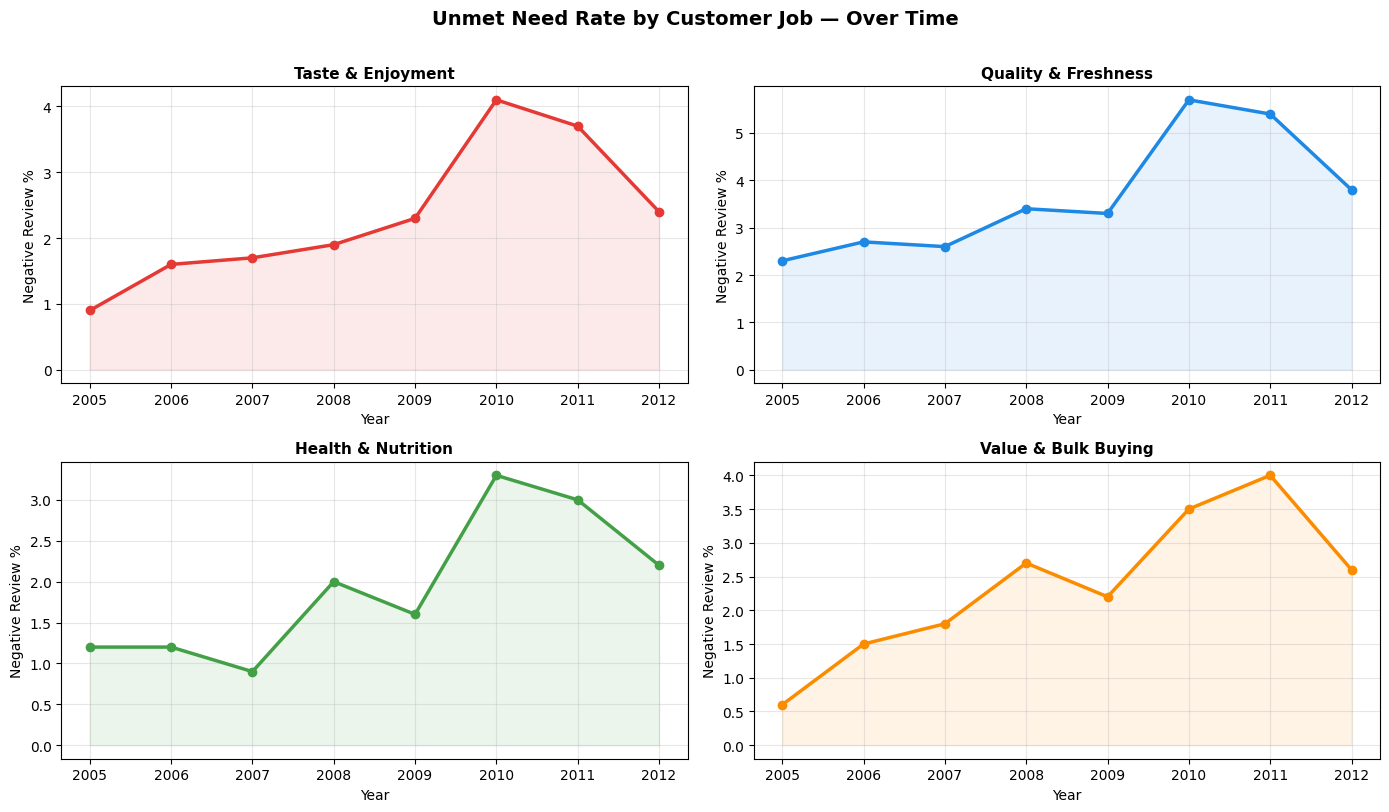

In [42]:
# Do certain jobs get worse over time? Better?
# Add year to df_sample first
df_sample['year'] = df_sample['review_date'].dt.year

# Refresh df_tags to pick up year + unmet_need columns
df_tags = df_sample.explode('jtbd_tags').reset_index(drop=True)

print(f"✓ df_tags refreshed: {len(df_tags):,} rows")
print(f"Columns: {df_tags.columns.tolist()}")

df_sample['year'] = df_sample['review_date'].dt.year

trend_df = df_tags.groupby(['year', 'jtbd_tags']).agg(
    total_reviews=('Id', 'count'),
    negative_reviews=('unmet_need', 'sum')
).reset_index()

trend_df['neg_rate'] = (trend_df['negative_reviews'] / trend_df['total_reviews']).round(3)

# Plot top 4 JTBD jobs over time
top_jobs = df_tags['jtbd_tags'].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

colors = ['#e53935', '#1e88e5', '#43a047', '#fb8c00']

for i, job in enumerate(top_jobs):
    job_trend = trend_df[
        (trend_df['jtbd_tags'] == job) & (trend_df['year'] >= 2005)
    ].sort_values('year')

    axes[i].plot(job_trend['year'], job_trend['neg_rate'] * 100,
                 color=colors[i], linewidth=2.5, marker='o', markersize=6)
    axes[i].set_title(f'{job}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Negative Review %')
    axes[i].set_xlabel('Year')
    axes[i].fill_between(job_trend['year'], job_trend['neg_rate'] * 100,
                          alpha=0.1, color=colors[i])
    axes[i].grid(alpha=0.3)

plt.suptitle('Unmet Need Rate by Customer Job — Over Time', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('trend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
import shutil
shutil.copy('trend_analysis.png', CHECKPOINT_PATH + 'trend_analysis.png')
print("✓ Trend analysis saved to Drive")

✓ Trend analysis saved to Drive


In [45]:
# Recreate missing columns
df_sample['review_length'] = df_sample['Text'].str.len()
df_sample['word_count'] = df_sample['clean_text'].str.split().str.len()

print("✓ Columns added")
print(df_sample[['review_length', 'word_count']].describe())


# Export 1: Main review-level data
export_cols = [
    'Id', 'ProductId', 'Score', 'review_year', 'review_month',
    'star_sentiment', 'vader_sentiment', 'vader_compound',
    'sentiment_agreement', 'helpfulness_ratio', 'is_helpful',
    'jtbd_count', 'unmet_need', 'lda_topic_name', 'lda_topic_confidence',
    'cluster_name', 'review_length', 'word_count'
]
df_sample[export_cols].to_csv('jtbd_reviews_main.csv', index=False)

# Export 2: JTBD tag-level (exploded)
df_tags[['Id', 'jtbd_tags', 'Score', 'star_sentiment', 'vader_compound',
          'unmet_need', 'is_helpful', 'review_year', 'cluster_name']].to_csv(
    'jtbd_tags_exploded.csv', index=False
)

# Export 3: Unmet needs summary
unmet_by_job.reset_index().to_csv('unmet_needs_summary.csv', index=False)

# Export 4: Topic-sentiment crosswalk
topic_sent = df_sample.groupby(['lda_topic_name', 'star_sentiment']).agg(
    count=('Id', 'count'),
    avg_rating=('Score', 'mean'),
    avg_helpfulness=('helpfulness_ratio', 'mean')
).reset_index()
topic_sent.to_csv('topic_sentiment_crosswalk.csv', index=False)

# Export 5: Cluster profiles
cluster_profile = df_sample.groupby('cluster_name').agg(
    review_count=('Id', 'count'),
    avg_rating=('Score', 'mean'),
    avg_vader=('vader_compound', 'mean'),
    unmet_need_rate=('unmet_need', 'mean'),
    helpful_rate=('is_helpful', 'mean')
).round(3).reset_index()
cluster_profile.to_csv('cluster_profiles.csv', index=False)

print("✓ All files exported!")
print("\nFiles created:")
for f in ['jtbd_reviews_main.csv', 'jtbd_tags_exploded.csv',
          'unmet_needs_summary.csv', 'topic_sentiment_crosswalk.csv',
          'cluster_profiles.csv']:
    print(f"  {f}")

✓ Columns added
       review_length     word_count
count  100001.000000  100001.000000
mean      528.109929      42.965330
std       570.248213      47.597987
min        32.000000       0.000000
25%       204.000000      16.000000
50%       359.000000      29.000000
75%       641.000000      52.000000
max     21409.000000    1843.000000
✓ All files exported!

Files created:
  jtbd_reviews_main.csv
  jtbd_tags_exploded.csv
  unmet_needs_summary.csv
  topic_sentiment_crosswalk.csv
  cluster_profiles.csv


In [46]:
import shutil
import os

files_to_save = [
    'jtbd_reviews_main.csv',
    'jtbd_tags_exploded.csv',
    'unmet_needs_summary.csv',
    'topic_sentiment_crosswalk.csv',
    'cluster_profiles.csv',
    'elbow_plot.png',
    'cluster_analysis.png',
    'helpfulness_model.png',
    'wordclouds.png',
    'trend_analysis.png'
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, CHECKPOINT_PATH + f)
        print(f"✓ {f}")
    else:
        print(f"✗ MISSING: {f}")

✓ jtbd_reviews_main.csv
✓ jtbd_tags_exploded.csv
✓ unmet_needs_summary.csv
✓ topic_sentiment_crosswalk.csv
✓ cluster_profiles.csv
✓ elbow_plot.png
✓ cluster_analysis.png
✓ helpfulness_model.png
✓ wordclouds.png
✓ trend_analysis.png
